### Test notebook

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import EMSigma_baseline as EM0_base
import EMSigma_4_11_26 as EM0_Class

#EM0 = EM0_Class.Eikonal_Model()

/workspaces/Eikonal-Model-Reaction-cross-section-code/Baseline_Code_Jupyter_Notebook/EMSigma_4_11_26.py:1: SyntaxWarning: invalid escape sequence '\F'
  """


In [2]:
cross_section = EM0_Class.cross_section()
Profile_Function = EM0_Class.Profile_Function()

In [3]:
#test vectors
a, theta_a = 2.0, np.pi/3.0
b, theta_b = 3.0, np.pi/4.0
c, theta_c = 4.0, np.pi/6.0

print("Baseline    :", EM0_base.add_sub_vec_mag(a, theta_a, b, theta_b, c, theta_c))
print("Updated Code:", cross_section.add_sub_vec_mag(a, theta_a, b, theta_b, c, theta_c))

Baseline    : 1.8848033382770102
Updated Code: 1.8848033382770102


/workspaces/Eikonal-Model-Reaction-cross-section-code/Baseline_Code_Jupyter_Notebook/EMSigma_baseline.py:180: RuntimeWarning: divide by zero encountered in divide
  arg = (1 + np.exp((r - C_m_p)/a_m_p))
/workspaces/Eikonal-Model-Reaction-cross-section-code/Baseline_Code_Jupyter_Notebook/EMSigma_4_11_26.py:503: RuntimeWarning: divide by zero encountered in divide
  return self.rho_0_p /(1 + np.exp((r - self.C_m_p)/self.a_m_p))


Baseline    : 0.0
Updated Code: 0.0


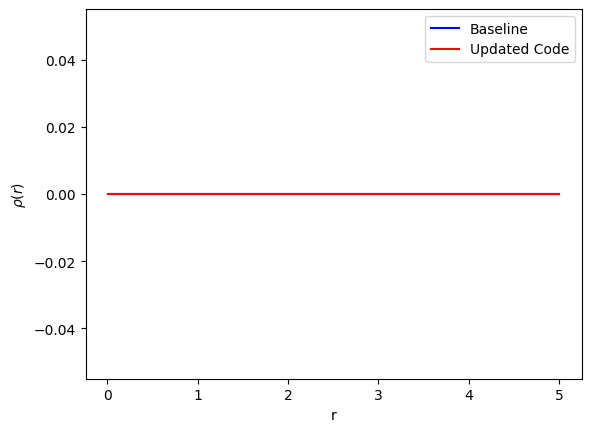

In [4]:
test_dens = EM0_Class.Density()
test_mesh = np.linspace(0.01,5, 30)
print("Baseline    :", EM0_base.rho_m(test_mesh )[-1])
print("Updated Code:", test_dens.rho_m(test_mesh )[-1])

plt.plot(test_mesh, EM0_base.rho_m(test_mesh ), color = "blue", label = "Baseline")
plt.plot(test_mesh, test_dens.rho_m(test_mesh ), color = "red", label = "Updated Code")
plt.xlabel("r")
plt.ylabel(r"$\rho(r)$")
plt.legend()
plt.show()

### $\Gamma(b)$ Section

In [5]:
b = 3.0
print("Baseline    :", EM0_base.Gamma(b))

Profile_Function.alpha = 1.808
Profile_Function.beta =  .268 
Profile_Function.sigma_n = 3.16

print("Updated Code:", Profile_Function.Gamma(b))


Baseline    : (4.7872304350836485e-08-8.655312626631236e-08j)
Updated Code: (4.7872304350836485e-08-8.655312626631235e-08j)


In [6]:
E = 325 #MeV
EM0_base.profile_funct_param(E, interaction_type = "matter")

Profile_Function = EM0_Class.Profile_Function(Model_type = "matter", E = 325)

#What is going on 

Gamma_W = lambda b:  (1 - 1j * 0.305) / (4 * np.pi * 0.075) * 3.03 * np.exp(-b**2 / (2 * 0.075))

b = 3.0
print("Baseline    :", EM0_base.Gamma(b))
print("Updated Code:", Profile_Function.Gamma(b))
print("test test   :", Gamma_W(b))

Baseline    : (2.815156783683478e-26-8.586228190234607e-27j)
Updated Code: (2.815156783683478e-26-8.586228190234607e-27j)
test test   : (2.815156783683478e-26-8.586228190234607e-27j)


In [7]:
E = 300 #MeV
EM0_base.profile_funct_param(E, interaction_type = "np")

Profile_Function = EM0_Class.Profile_Function(Model_type = "np", E = 300)

b = 3.0
print("Baseline    :", EM0_base.Gamma(b))
print("Updated Code:", Profile_Function.Gamma(b))

Baseline    : (2.7104334286135547e-24-8.836071405087366e-25j)
Updated Code: (0.0008840258559260083-0.0008840258559260083j)


### Cross section 

Baseline    : 0.8433016800849275
Updated Code: 0.8433016800849275


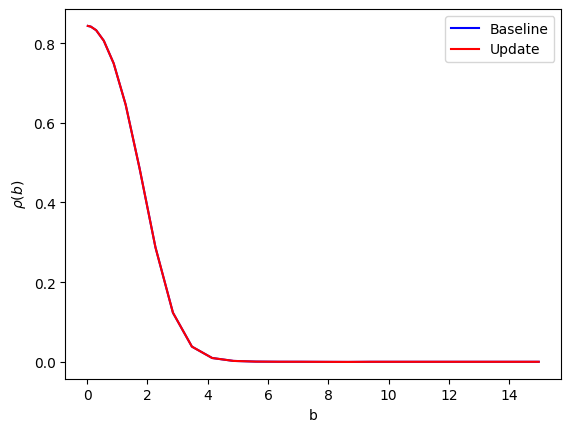

In [8]:
#Loading the densites
C = np.genfromtxt("Cor_dens_Update/Cor_Ca_C_Mass_dens/12Crho-mass.txt", unpack= True) 
C_r_mesh = np.genfromtxt("Cor_dens_Update/Cor_Ca_C_Mass_dens/12C_radius.txt", unpack= True)

C_rho_baseline = EM0_base.dens_b_interpolator(C_r_mesh[0],C[0])
C_rho_update = cross_section.dens_b_interpolator(C_r_mesh[0],C[0])

print("Baseline    :", C_rho_baseline[0])
print("Updated Code:", C_rho_update[0])

plt.plot(EM0_base.t_mapped_roots.tolist(),C_rho_baseline, color = "blue", label = "Baseline")
plt.plot( cross_section.t_mapped_roots.tolist(),C_rho_update, color = "red", label = "Update")

plt.xlabel("b")
plt.ylabel(r"$\rho(b)$")
plt.legend()
plt.show()

In [9]:
#Load in densities
C_r_Filename = np.array(["Cor_dens_Update/Cor_Ca_C_Mass_dens/12C_radius.txt",])     
C_p_Filename = np.array(["Cor_dens_Update/Cor_Ca_C_Mass_dens/12Crho-prot.txt",])
C_n_Filename = np.array(["Cor_dens_Update/Cor_Ca_C_Mass_dens/12Crho-neut.txt",])
C_p = np.genfromtxt(C_p_Filename[0], unpack= True)
C_r_mesh = np.genfromtxt(C_r_Filename[0], unpack= True)
C_n = np.genfromtxt(C_n_Filename[0], unpack= True)

C_rho_p = cross_section.dens_b_interpolator(C_r_mesh[0], C_p[0]) 
C_rho_n = cross_section.dens_b_interpolator(C_r_mesh[0], C_n[0])

Ca_r_Filename = np.array(["Cor_dens_Update/Cor_Ca_C_Mass_dens/42Ca_radius.txt",])     
Ca_p_Filename = np.array(["Cor_dens_Update/Cor_Ca_C_Mass_dens/42Carho-prot.txt",])
Ca_n_Filename = np.array(["Cor_dens_Update/Cor_Ca_C_Mass_dens/42Carho-neut.txt",])
Ca_p = np.genfromtxt(Ca_p_Filename[0], unpack= True)
Ca_r_mesh = np.genfromtxt(Ca_r_Filename[0], unpack= True)
Ca_n = np.genfromtxt(Ca_n_Filename[0], unpack= True)

Ca_rho_p = cross_section.dens_b_interpolator(Ca_r_mesh[0], Ca_p[0]) 
Ca_rho_n = cross_section.dens_b_interpolator(Ca_r_mesh[0], Ca_n[0])


In [10]:
b = 3
rho_t = C_rho_p + C_rho_n
rho_p = Ca_rho_p +Ca_rho_n

EM0_base.profile_funct_param(E, interaction_type = "matter")
Profile_Function = EM0_Class.Profile_Function(Model_type = "matter", E = E)

print("Baseline    :", EM0_base.Chi_mol_1(b, rho_t, rho_p, EM0_base.Gamma))
print("Updated Code:",cross_section.Chi_mol_1(b, rho_t, rho_p, Profile_Function.Gamma))

Baseline    : (0.9052150179083368+3.6708610816324434j)
Updated Code: (0.9052150179083368+3.6708610816324434j)


In [11]:
print("Baseline    :", EM0_base.Chi_mol(b, rho_t, rho_p, EM0_base.Gamma))
print("Updated Code:",cross_section.Chi_mol(b, rho_t, rho_p, Profile_Function.Gamma))

Baseline    : (1.4922912865351385+6.750296459816488j)
Updated Code: (1.4922912865351385+6.750296459816488j)


In [12]:
print("Baseline    :", EM0_base.chi(b, rho_t, rho_p, EM0_base.Gamma))
print("Updated Code:", cross_section.chi(b, rho_t, rho_p, Profile_Function.Gamma))

Baseline    : (3.6684109566275986+10.003952729399622j)
Updated Code: (3.6684109566275986+10.003952729399622j)


In [13]:
print("Baseline    :",EM0_base.chi_no_dens(b , C_rho_p + C_rho_p, EM0_base.Gamma)) 
print("Updated Code:",cross_section.chi_no_dens(b , C_rho_p, C_rho_p, EM0_base.Gamma, EM0_base.Gamma)) 


Baseline    : (0.03813593629622242+0.10399873637645267j)
Updated Code: (0.03813593629622242+0.10399873637645267j)


In [14]:
print("Baseline    :",EM0_base.sigma_R( rho_t,  rho_p  = rho_p , Gamma = EM0_base.Gamma, Model = "MOL"))
print("Updated Code:", cross_section.sigma_R_matter( rho_t,  rho_p  = rho_p , Gamma = Profile_Function.Gamma, Model = "MOL"))

Baseline    : 1460.7945171365964
Updated Code: 1460.7945171365964


In [15]:
print("Baseline    :",EM0_base.sigma_R( rho_t,  rho_p  = rho_p , Gamma = EM0_base.Gamma, Model = "OLA"))
print("Updated Code:",cross_section.sigma_R_matter( rho_t,  rho_p  = rho_p , Gamma = Profile_Function.Gamma, Model = "OLA"))


Baseline    : 1501.4106333971436
Updated Code: 1501.4106333971436


Baseline    : 367.9933286168955
Updated Code: 367.9933286168955


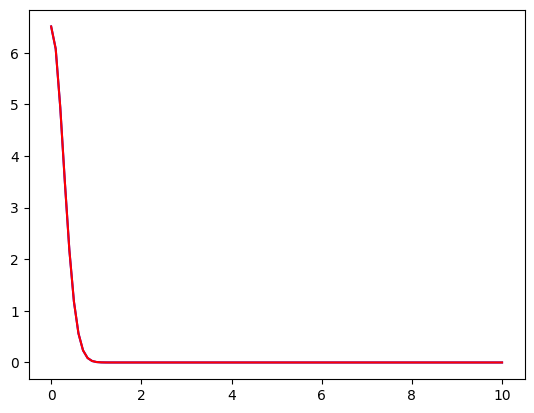

In [ ]:
E = 300 #MeV
EM0_base.profile_funct_param(E, interaction_type = "np")
Profile_Function = EM0_Class.Profile_Function(Model_type = "np", E = E)

b_mesh = np.linspace(0, 10, 100)
test_gamma = lambda b: Profile_Function.Gamma_pp(b) + Profile_Function.Gamma_pn(b)

plt.plot(b_mesh, EM0_base.Gamma(b_mesh), color = "b")
plt.plot(b_mesh, test_gamma(b_mesh), color = "r" )

print("Baseline    :",EM0_base.sigma_R( Ca_rho_p, Gamma = EM0_base.Gamma, Model = "OLA p-n"))
print("Updated Code:",cross_section.sigma_R_pn( Ca_rho_p, Ca_rho_p,
                                               Gamma_pp = Profile_Function.Gamma_pp, 
                                               Gamma_pn = Profile_Function.Gamma_pn,  Model = "OLA p-n"))


In [17]:
b = 3
rho_t_p = C_rho_p 
rho_t_n = C_rho_n
rho_p_p = Ca_rho_p 
rho_p_n = Ca_rho_n

print("Baseline    :",EM0_base.chi_mol_micro(b, rho_t_p, rho_t_n, rho_p_n,rho_p_p, EM0_base.Gammap, EM0_base.Gamman, EM0_base.Gammap))
print("Updated Code:",cross_section.chi_mol_micro(b, rho_t_p, rho_t_n, rho_p_n,rho_p_p, EM0_base.Gammap, EM0_base.Gamman, EM0_base.Gammap))


Baseline    : (2.7947105077279386+8.14095608857362j)
Updated Code: (2.7947105077279386+8.14095608857362j)


In [18]:
print("Baseline    :", EM0_base.chi_ola_micro(b, rho_t_p, rho_t_n, rho_p_n,rho_p_p, EM0_base.Gammap, EM0_base.Gamman, EM0_base.Gammap) )
print("Updated Code:", cross_section.chi_ola_micro(b, rho_t_p, rho_t_n, rho_p_n,rho_p_p, EM0_base.Gammap, EM0_base.Gamman, EM0_base.Gammap))

Baseline    : (4.416526727148994+9.933877533380189j)
Updated Code: (4.416526727148994+9.933877533380189j)


In [19]:
print("Baseline    :",EM0_base.sigma_R_micro(rho_t_p, rho_t_n, rho_p_p, rho_p_n, 
                             EM0_base.Gammap, EM0_base.Gamman, EM0_base.Gammap , Model = "OLA"))
print("Updated Code:",cross_section.sigma_R_pn(rho_t_p, rho_t_n, rho_p_p, rho_p_n, 
                             EM0_base.Gammap, EM0_base.Gamman, EM0_base.Gammap, Model = "OLA"))



Baseline    : 1498.562124234784
Updated Code: 1498.562124234784


In [20]:
print("Baseline    :",EM0_base.sigma_R_micro(rho_t_p, rho_t_n, rho_p_p, rho_p_n, 
                             EM0_base.Gammap, EM0_base.Gamman, EM0_base.Gammap , Model = "MOL"))
print("Updated Code:",cross_section.sigma_R_pn(rho_t_p, rho_t_n, rho_p_p, rho_p_n, 
                             EM0_base.Gammap, EM0_base.Gamman, EM0_base.Gammap  , Model = "MOL"))

Baseline    : 1478.8960071742963
Updated Code: 1478.8960071742963


In [21]:
test_dens = EM0_Class.Density()
A = 42
Z = 20 

print ("Baseline     :",[3.4481556494276426, 3.4481556494276426, 0.014023505542324788])
print ("Updated code :", test_dens.rms(Ca_r_mesh[1] ,Ca_p[1] + Ca_n[1], A), test_dens.rms(Ca_r_mesh[1], Ca_p[1] + Ca_n[1], A), -test_dens.rms(Ca_r_mesh[1], Ca_p[1],Z) + test_dens.rms(Ca_r_mesh[1], Ca_n[1], A-Z ) )

Baseline     : [3.4481556494276426, 3.4481556494276426, 0.014023505542324788]
Updated code : 3.4481556494276426 3.4481556494276426 0.014023505542324788
